In [187]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa
from matplotlib.pyplot import imshow
import matplotlib.cm as cm
from matplotlib.pyplot import contourf
from refractiveindex import RefractiveIndexMaterial

In [188]:
m = 1 # angular momentum number under consideration
lambda_air = 532 # wavelength in air in nm
R = 5.1 # Radius of the cylindrical scatterer
x = (2*pi/lambda_air)*R # kR
N = 10000
epsilons_m_1 = linspace(-1.02, -1, N) + 0j
s_arr_m_1 = h_z_cpa(m, x, epsilons_m_1);
m = 2 # angular momentum number under consideration
epsilons_m_2 = linspace(-1.001222, -1.0012, N) + 0j
s_arr_m_2 = h_z_cpa(m, x, epsilons_m_2);

## The paper states that $s=-1$ for $\epsilon \approx -1.01$ for $m=1$ and $\epsilon \approx -1.001$ for $m=2$. We verify this in the below.

m = 1
Epsilon at which Re(s) is closest to -1:  -1.0116
Epsilon at which Im(s) is closest to 0:  -1.0116
m = 2
Epsilon at which Re(s) is closest to -1:  -1.0012
Epsilon at which Im(s) is closest to 0:  -1.0012


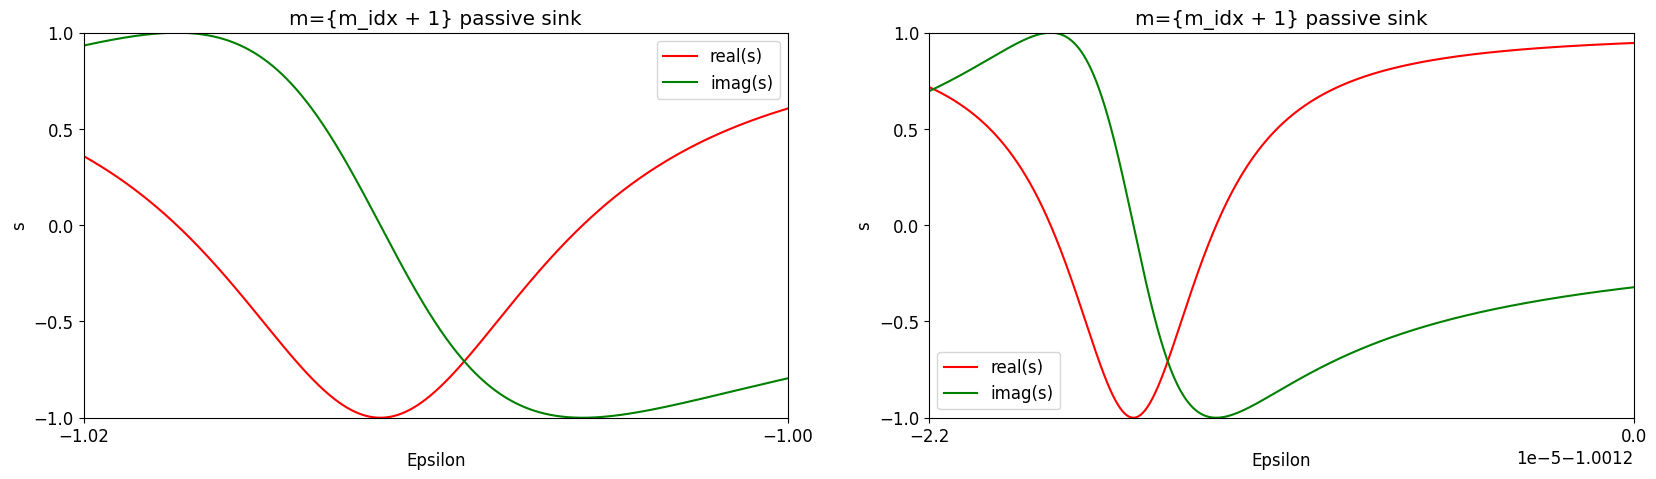

In [189]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
for (m_idx, (epsilons, s_arr, ax)) in enumerate(zip((epsilons_m_1, epsilons_m_2), (s_arr_m_1, s_arr_m_2), (ax1, ax2))):
    epsilon_min = epsilons.real.min()
    epsilon_max = epsilons.real.max()
    ax.plot(epsilons.real, s_arr.real, label="real(s)", color="red")
    ax.plot(epsilons.real, s_arr.imag, label="imag(s)", color="green")
    ax.set_xlim(epsilon_min, epsilon_max);
    ax.set_ylim(-1, 1);
    ax.set_xticks([epsilon_min, epsilon_max])
    ax.set_yticks(linspace(-1, 1, 5))
    ax.set_xlabel("Epsilon")
    ax.set_ylabel("s")
    ax.legend();
    print(f"m = {m_idx + 1}")
    print("Epsilon at which Re(s) is closest to -1: ", epsilons[np.abs(s_arr.real+1).argmin()].round(4).real)
    print("Epsilon at which Im(s) is closest to 0: ", epsilons[np.abs(s_arr.imag).argmin()].round(4).real)
    ax.set_title("m={m_idx + 1} passive sink");

## Figure 4a 

In [190]:
re_epsilon = epsilons_m_1[np.abs(s_arr_m_1.real+1).argmin()].real
N = 10000
m = 1
epsilons_4_a = re_epsilon + 1j*linspace(0, 0.01, N)
s_arr_4_a = h_z_cpa(m, x, epsilons_4_a);

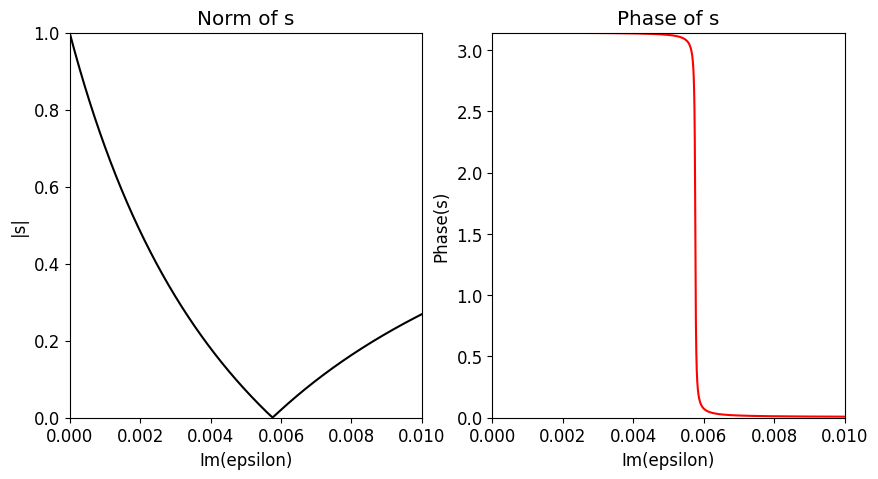

In [191]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(epsilons_4_a.imag, np.abs(s_arr_4_a), color="black")
ax1.set_xlim(epsilons_4_a.imag.min(), epsilons_4_a.imag.max())
ax1.set_ylim(0, 1)
ax1.set_xlabel("Im(epsilon)")
ax1.set_ylabel("|s|")
ax1.set_title("Norm of s")
ax2.plot(epsilons_4_a.imag, np.angle(s_arr_4_a), color="red")
ax2.set_xlim(epsilons_4_a.imag.min(), epsilons_4_a.imag.max())
ax2.set_ylim(0, np.pi);
ax2.set_xlabel("Im(epsilon)")
ax2.set_ylabel("Phase(s)")
ax2.set_title("Phase of s");

## Figure 2

### We first make the linear scale plots (2a, 2c)

In [337]:
# Electric field in the radial direction
def E_vacuum_rho(m, lambda_air, r):
    kr = (2*pi/lambda_air)*r
    return (1j*m/r)*jv(m, kr)
# Electric field in the azimuthal direction
def E_vacuum_theta(m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    return -k*jvp(m, kr)
# Electric field in the radial direction (for r>R)
def E_scatterer_rho_gt(m, lambda_air, r):
    kr = (2*pi/lambda_air)*r
    return (1j*m/r)*yv(m, kr)
# Electric field in the azimuthal direction (for r>R)
def E_scatterer_theta_gt(m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    return -k*yvp(m, kr)
# Electric field in the radial direction (for r>R)
def E_scatterer_rho_lt(m, lambda_air, r, R, epsilon):
    n = sqrt(epsilon)
    kr = (2*pi/lambda_air)*r
    kR = (2*pi/lambda_air)*R

    return (1j*m/r)*jv(m, n*kr)*yv(m, kR)/jv(m, n*kR)/epsilon
# Electric field in the azimuthal direction (for r>R)
def E_scatterer_theta_lt(m, lambda_air, r, R, epsilon):
    n = sqrt(epsilon)
    k = (2*pi/lambda_air)
    kr = k*r
    kR = k*R
    return -n*k*jvp(m, n*kr)*yv(m, k*R)/jv(m, n*kR)/epsilon
    
def E_scatterer_rho(m, lambda_air, r, R, epsilon):
    return np.where(r<R, E_scatterer_rho_lt(m, lambda_air, r, R, epsilon), E_scatterer_rho_gt(m, lambda_air, r))
# Electric field in the azimuthal direction (for r>R)
def E_scatterer_theta(m, lambda_air, r, R, epsilon):
    return np.where(r<R, E_scatterer_theta_lt(m, lambda_air, r, R, epsilon), E_scatterer_theta_gt(m, lambda_air, r))

In [338]:
lambda_air = 532 # wavelength in air in nm
R = 5.1 # Radius of the cylindrical scatterer
N = 10000
rs_vacuum = linspace(0.1, 180, N)
rs_scatterer = linspace(0.1, 180, N)

In [339]:
vacuum_intensities = []
scatterer_intensities = []
ms = [1, 2]
epsilon = -1 + 0j
for m in ms:
    vacuum_intensity = np.abs(E_vacuum_rho(m, lambda_air, rs_vacuum))**2 + np.abs(E_vacuum_theta(m, lambda_air, rs_vacuum))**2;
    scatterer_intensity = np.abs(E_scatterer_rho(m, lambda_air, rs_scatterer, R, epsilon))**2 + np.abs(E_scatterer_theta(m, lambda_air, rs_scatterer, R, epsilon))**2;
    vacuum_intensities.append(vacuum_intensity)
    scatterer_intensities.append(scatterer_intensity)

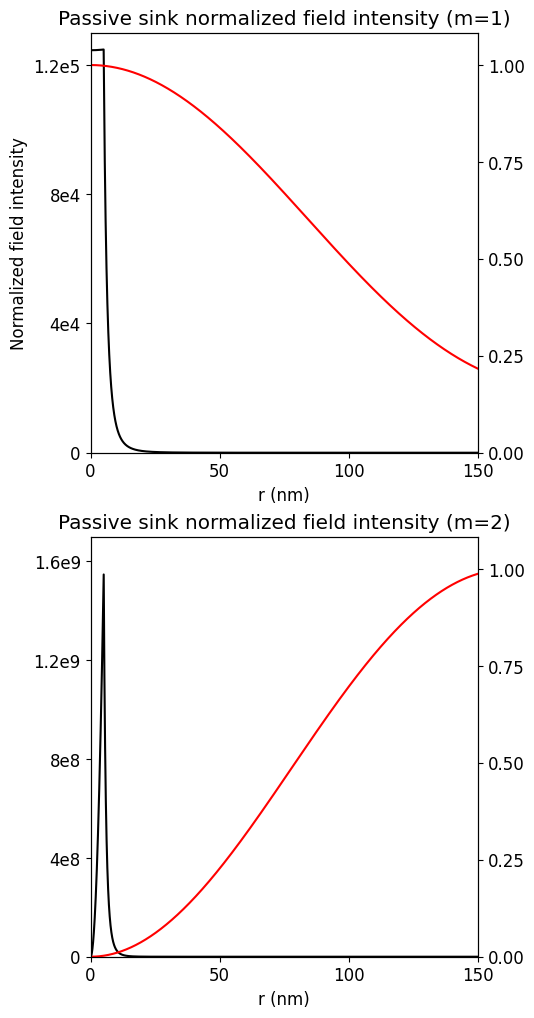

In [342]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 12))
for (ax_idx, ax) in enumerate((ax1, ax2)):
    vacuum_intensity = vacuum_intensities[ax_idx]
    scatterer_intensity = scatterer_intensities[ax_idx]
    max_vacuum_intensity = vacuum_intensity.max()
    m = ms[ax_idx]
    ax_twin = ax.twinx()
    ax.plot(rs_scatterer, scatterer_intensity/max_vacuum_intensity, color="black", label="Scatterer intensity")
    ax_twin.plot(rs_vacuum, vacuum_intensity/max_vacuum_intensity, color="red", label="Vacuum intensity")
    ax.set_xlim(0, 150)
    ax_twin.set_ylim(0, 1.083333)
    if ax_idx == 0:
        ax.set_yticks([0, 4e4, 8e4, 1.2e5], ["0", "4e4", "8e4", "1.2e5"])
        ax.set_ylim(0, 1.3e5)
    else: 
        ax.set_yticks([0, 4e8, 8e8, 1.2e9, 1.6e9], ["0", "4e8", "8e8", "1.2e9", "1.6e9"])
        ax.set_ylim(0, 1.7e9)
    ax_twin.set_yticks(linspace(0, 1, 5));
    ax.set_xticks(linspace(0, 150, 4));
    ax.set_xlabel("r (nm)");
    if ax_idx == 0:
        ax.set_ylabel("Normalized field intensity");
    ax.set_title(f"Passive sink normalized field intensity (m={m})");

## Now we make the log plots (2b, 2d)

In [343]:
lambda_air = 532 # wavelength in air in nm
R = 5.1 # Radius of the cylindrical scatterer
N = 10000
rs_vacuum = linspace(0.1, 350, N)
rs_scatterer = linspace(0.1, 350, N)

In [345]:
vacuum_intensities = []
scatterer_intensities = []
ms = [1, 2]
for m in ms:
    vacuum_intensity = np.abs(E_vacuum_rho(m, lambda_air, rs_vacuum))**2 + np.abs(E_vacuum_theta(m, lambda_air, rs_vacuum))**2;
    scatterer_intensity = np.abs(E_scatterer_rho(m, lambda_air, rs_scatterer, R, epsilon))**2 + np.abs(E_scatterer_theta(m, lambda_air, rs_scatterer, R, epsilon))**2;
    vacuum_intensities.append(vacuum_intensity)
    scatterer_intensities.append(scatterer_intensity)

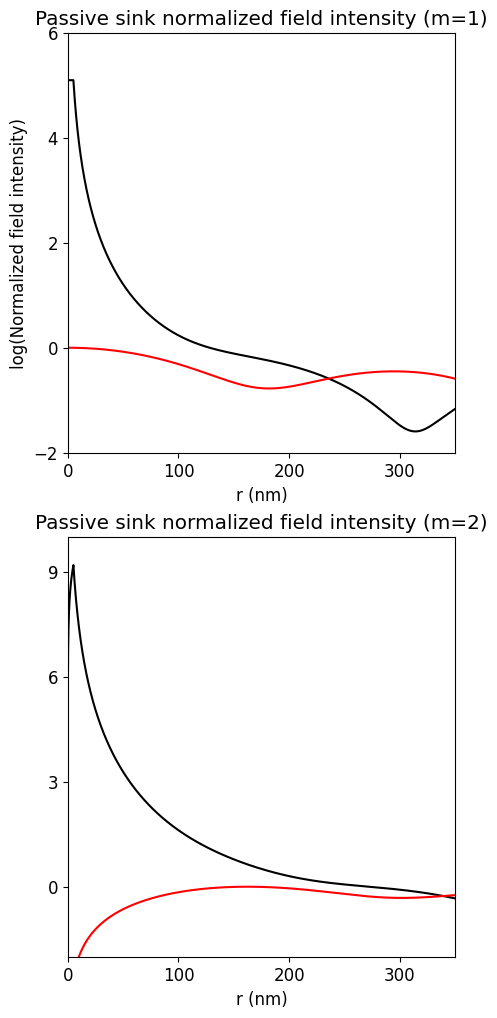

In [346]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 12))
for (ax_idx, ax) in enumerate((ax1, ax2)):
    vacuum_intensity = vacuum_intensities[ax_idx]
    scatterer_intensity = scatterer_intensities[ax_idx]
    max_vacuum_intensity = vacuum_intensity.max()
    m = ms[ax_idx]
    ax.plot(rs_scatterer, np.log10(scatterer_intensity/max_vacuum_intensity), color="black", label="Scatterer intensity")
    ax.plot(rs_vacuum, np.log10(vacuum_intensity/max_vacuum_intensity), color="red", label="Vacuum intensity")
    ax.set_xlim(0, 350)
    if ax_idx == 0:
        ax.set_yticks(linspace(-2, 6, 5))
        ax.set_ylim(-2, 6)
        #ax_twin.set_ylim(-2, 6)
    else: 
        ax.set_yticks(linspace(0, 9, 4))
        ax.set_ylim(-2, 10)
    ax.set_xticks(linspace(0, 300, 4));
    ax.set_xlabel("r (nm)");
    if ax_idx == 0:
        ax.set_ylabel("log(Normalized field intensity)");
    ax.set_title(f"Passive sink normalized field intensity (m={m})");